In [8]:
import warnings
warnings.filterwarnings("ignore")

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
BC_dataset = sklearn.datasets.load_breast_cancer()

In [11]:
print(BC_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [12]:
df = pd.DataFrame(BC_dataset.data, columns= BC_dataset.feature_names)

In [8]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [22]:
df['label'] = BC_dataset.target

In [10]:
df.shape

(569, 31)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [12]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [13]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64

In [14]:
df['label'].value_counts()

label
1    357
0    212
Name: count, dtype: int64

# 1 --> Benign
# 0 --> Malignant

In [15]:
df.groupby('label').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


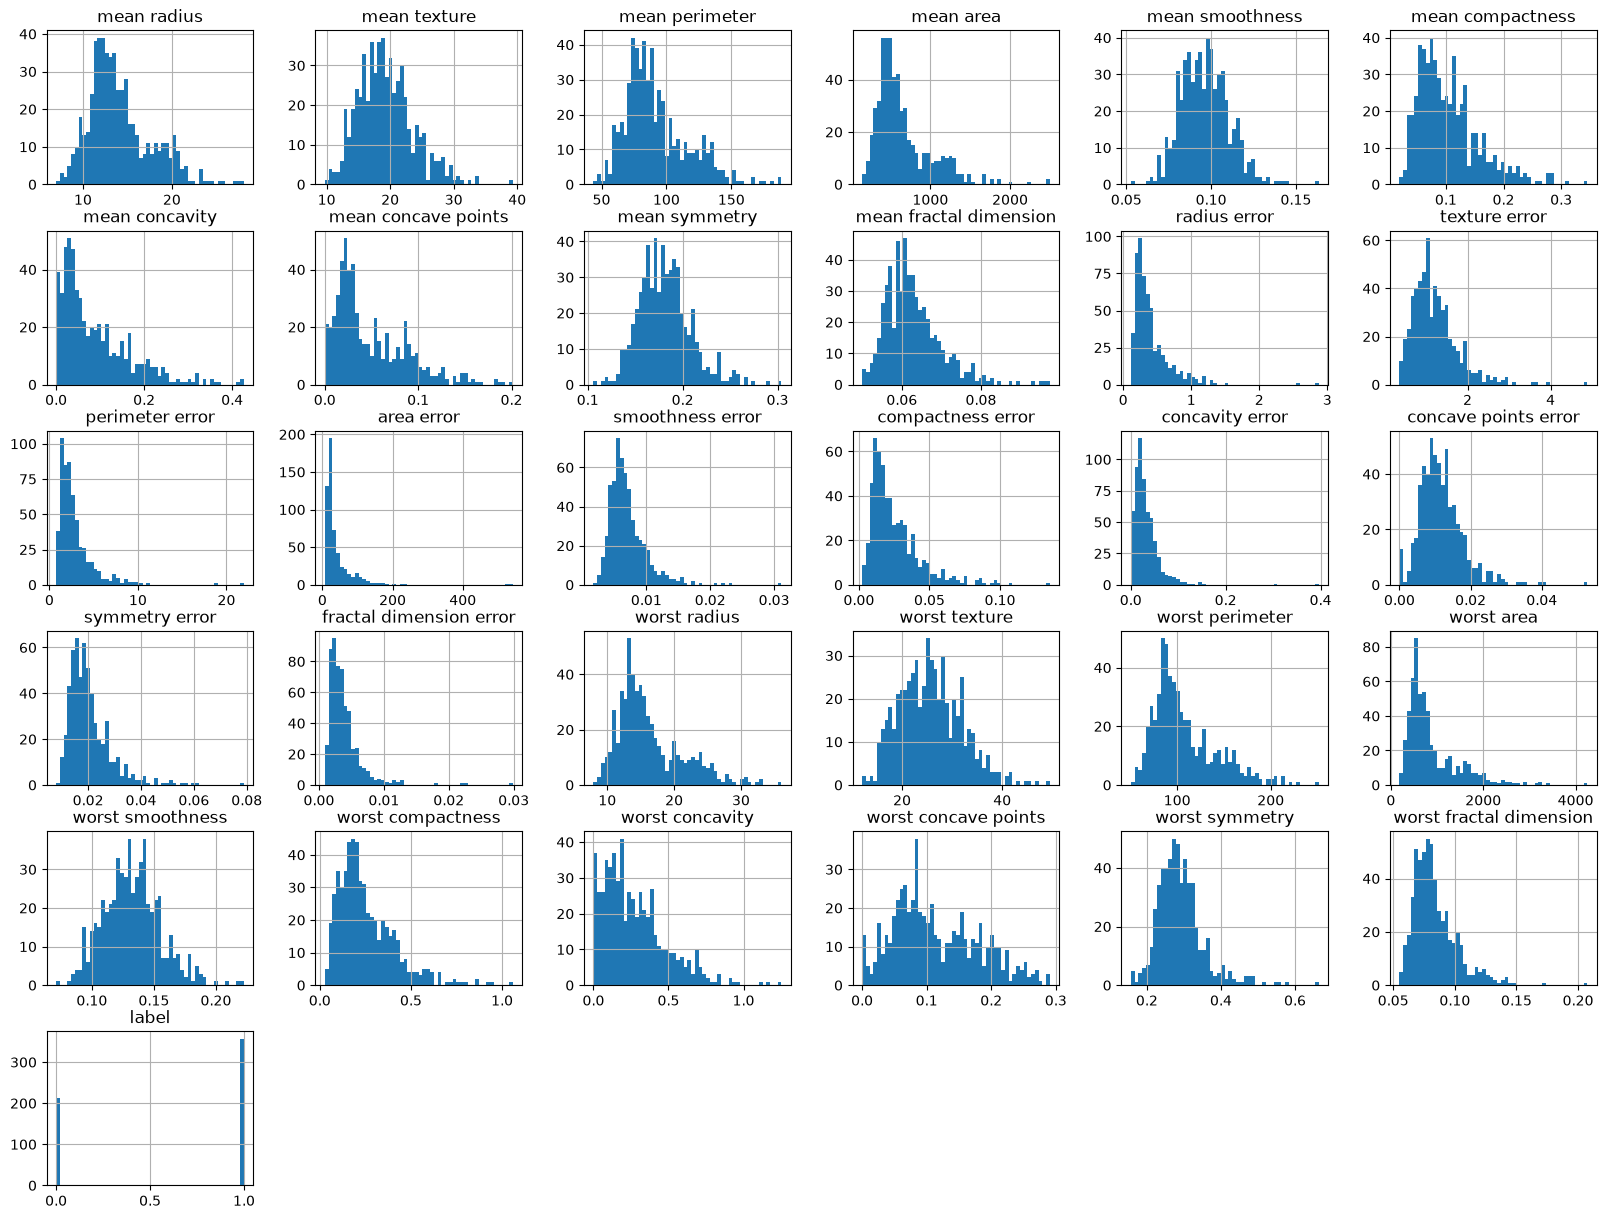

In [16]:
df.hist(bins=50, figsize=(20,15))
plt.show()

# ***Feature Selection***

In [23]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'label'],
      dtype='str')

In [14]:
X = df.drop(columns='label')
Y = df['label']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=.2, random_state=3)

In [16]:
print(x_train.shape)
print(x_test.shape)

(455, 30)
(114, 30)


In [17]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [35]:
from sklearn.tree import DecisionTreeClassifier

In [36]:
dtree = DecisionTreeClassifier()

In [37]:
dtree.fit(x_train_std,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
dtree.feature_importances_

array([0.00000000e+00, 3.50921570e-02, 0.00000000e+00, 0.00000000e+00,
       4.67376120e-03, 0.00000000e+00, 2.23080378e-03, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.49389627e-03, 1.37072075e-02,
       1.45331717e-02, 1.95089658e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 5.48129330e-04, 9.10272843e-03, 1.57173002e-01,
       4.49846581e-03, 7.78960199e-03, 1.32810991e-02, 7.07687168e-01,
       8.67984222e-03, 0.00000000e+00])

In [39]:
feature_importances = [(features, rfimportance) for features, rfimportance in zip(X.columns, dtree.feature_importances_)]

In [40]:
feature_df = pd.DataFrame(feature_importances, columns=['features', 'dtreeimportance'])

In [41]:
feature_df.sort_values(by=['dtreeimportance'], ascending=False)

,features,dtreeimportance
27,worst concave points,0.707687
23,worst area,0.157173
1,mean texture,0.035092
13,area error,0.019509
12,perimeter error,0.014533
11,texture error,0.013707
26,worst concavity,0.013281
22,worst perimeter,0.009103
28,worst symmetry,0.008680
25,worst compactness,0.007790


In [42]:
feature_df.sort_values(by=['dtreeimportance'], ascending=False)['features']

27       worst concave points
23                 worst area
1                mean texture
13                 area error
12            perimeter error
11              texture error
26            worst concavity
22            worst perimeter
28             worst symmetry
25          worst compactness
4             mean smoothness
24           worst smoothness
6              mean concavity
10               radius error
21              worst texture
8               mean symmetry
9      mean fractal dimension
7         mean concave points
0                 mean radius
2              mean perimeter
3                   mean area
5            mean compactness
20               worst radius
19    fractal dimension error
18             symmetry error
17       concave points error
15          compactness error
16            concavity error
14           smoothness error
29    worst fractal dimension
Name: features, dtype: str

In [23]:
featured_df = df[['worst concave points', 'worst area',	'mean perimeter',	'mean texture',	'area error',	'texture error',	'perimeter error',	'worst concavity',	'worst texture',
'worst perimeter',	'worst compactness',	'radius error', 'mean fractal dimension', 'worst smoothness', 'mean concave points']]

In [24]:
x_train, x_test, y_train, y_test = train_test_split(featured_df,Y, test_size=.2, random_state=3)

In [25]:
print(x_train.shape)
print(x_test.shape)

(455, 15)
(114, 15)


In [26]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

# ***Neural Network -- NN***

In [49]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [50]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(15,)),
    keras.layers.Dense(40, activation="relu"),
    keras.layers.Dense(2, activation="sigmoid")
])

In [51]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [52]:
history = model.fit(x_train_std, y_train, validation_split=.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5086 - loss: 0.7233 - val_accuracy: 0.7609 - val_loss: 0.5724
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8655 - loss: 0.4797 - val_accuracy: 0.9348 - val_loss: 0.4111
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9291 - loss: 0.3450 - val_accuracy: 0.9783 - val_loss: 0.3167
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9535 - loss: 0.2686 - val_accuracy: 0.9783 - val_loss: 0.2588
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9584 - loss: 0.2216 - val_accuracy: 0.9783 - val_loss: 0.2199
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9658 - loss: 0.1900 - val_accuracy: 0.9783 - val_loss: 0.1915
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9707 - loss: 0.1671 - val_accuracy: 0.9783 - val_loss: 0.1698
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9707 - loss: 0.1497 - val_accuracy: 0.9783 - val_loss

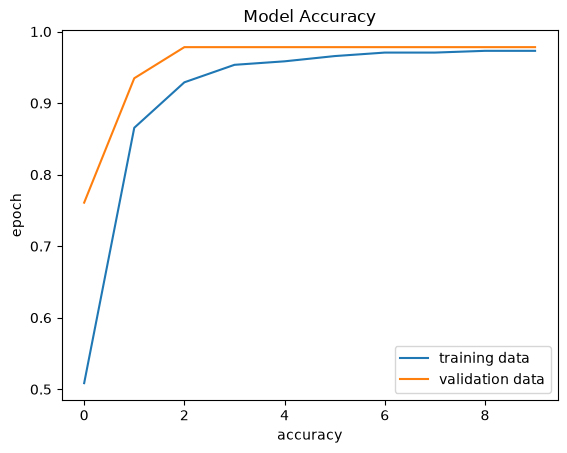

In [53]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("accuracy")
plt.ylabel("epoch")

plt.legend(["training data", "validation data"], loc="lower right")
plt.show()

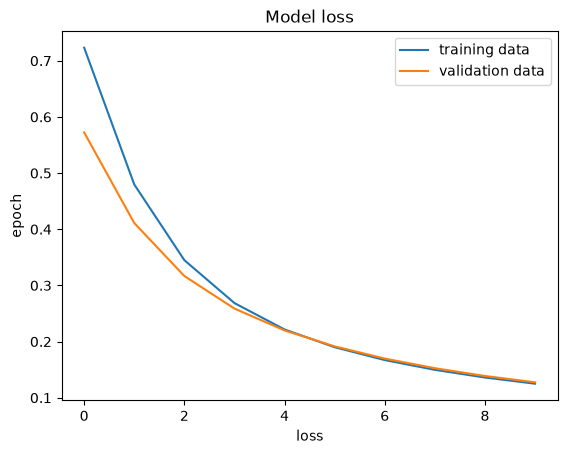

In [54]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model loss")
plt.xlabel("loss")
plt.ylabel("epoch")

plt.legend(["training data", "validation data"], loc="upper right")
plt.show()

# ***Model Accuracy***

In [55]:
loss, accuracy = model.evaluate(x_test_std, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9649 - loss: 0.1254


In [56]:
print(f"Model Accuracy is :{accuracy}")

Model Accuracy is :0.9649122953414917


In [57]:
y_pred = model.predict(x_test_std)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [58]:
print(y_pred.shape)
print(y_pred[0])

(114, 2)
[0.11445192 0.67718065]


In [60]:
print(np.argmax(y_pred[0]))

1


In [61]:
y_pred_labels = [np.argmax(i) for i in y_pred]

In [62]:
for i in y_pred_labels:
  print(i)

1
1
1
1
0
1
1
1
1
1
1
0
1
1
1
1
1
1
0
1
1
1
1
1
1
1
1
0
0
1
0
1
1
1
1
1
1
1
0
0
0
1
1
0
1
0
0
1
0
1
0
1
1
0
0
1
1
1
1
1
1
1
0
0
1
1
0
1
0
0
1
0
0
0
1
0
1
0
0
0
0
1
1
1
1
0
1
1
1
1
0
0
0
1
1
0
1
0
1
1
1
0
1
1
1
0
0
1
0
1
1
0
1
1


In [63]:
from sklearn.metrics import classification_report

In [64]:
print(classification_report(y_pred_labels, y_test))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        40
           1       0.97      0.97      0.97        74

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



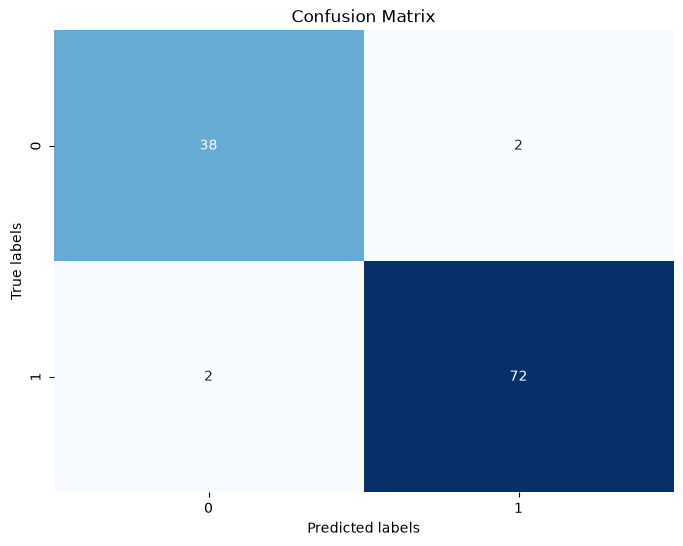

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_pred_labels, y_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

# ***Prediction System***

In [ ]:
def predict_label(input_data: tuple):
  input_data_as_np_array = np.asarray(input_data)

  input_array_reshaped = input_data_as_np_array.reshape(1,-1)

  std_input_data = scaler.transform(input_array_reshaped)

  prediction = model.predict(std_input_data)
  print(f"Prediction: {prediction}")

  label = np.argmax(prediction)
  print(f"Label: {label}")

  if label == 0:
    print("Tumor is Malignant")
  else:
    print("Tumor is Benign")


In [68]:
featured_df

,worst concave points,worst area,mean perimeter,mean texture,area error,texture error,perimeter error,worst concavity,worst texture,worst perimeter,worst compactness,radius error,mean fractal dimension,worst smoothness,mean concave points
0,0.2654,2019.0,122.80,10.38,153.40,0.9053,8.589,0.7119,17.33,184.60,0.66560,1.0950,0.07871,0.16220,0.14710
1,0.1860,1956.0,132.90,17.77,74.08,0.7339,3.398,0.2416,23.41,158.80,0.18660,0.5435,0.05667,0.12380,0.07017
2,0.2430,1709.0,130.00,21.25,94.03,0.7869,4.585,0.4504,25.53,152.50,0.42450,0.7456,0.05999,0.14440,0.12790
3,0.2575,567.7,77.58,20.38,27.23,1.1560,3.445,0.6869,26.50,98.87,0.86630,0.4956,0.09744,0.20980,0.10520
4,0.1625,1575.0,135.10,14.34,94.44,0.7813,5.438,0.4000,16.67,152.20,0.20500,0.7572,0.05883,0.13740,0.10430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.2216,2027.0,142.00,22.39,158.70,1.2560,7.673,0.4107,26.40,166.10,0.21130,1.1760,0.05623,0.14100,0.13890
565,0.1628,1731.0,131.20,28.25,99.04,2.4630,5.203,0.3215,38.25,155.00,0.19220,0.7655,0.05533,0.11660,0.09791
566,0.1418,1124.0,108.30,28.08,48.55,1.0750,3.425,0.3403,34.12,126.70,0.30940,0.4564,0.05648,0.11390,0.05302
567,0.2650,1821.0,140.10,29.33,86.22,1.5950,5.772,0.9387,39.42,184.60,0.86810,0.7260,0.07016,0.16500,0.15200


In [28]:
input_data = (0.2654,	2019.0,	122.80,	10.38,	153.40,	0.9053,	8.589,	0.7119,	17.33,	184.60,	0.66560,	1.0950,	0.07871,	0.16220,	0.14710)

predict_label(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
Prediction: [[0.9088451  0.03000098]]
Label: 0
Tumor is Malignant


In [70]:
featured_df.shape

(569, 15)

In [71]:
featured_df['label'] = BC_dataset.target

In [72]:
featured_df.shape

(569, 16)

In [73]:
featured_df.to_csv("Breast_Cancer_dataset_updated.csv")

In [34]:
featured_df.describe()

,worst concave points,worst area,mean perimeter,mean texture,area error,texture error,perimeter error,worst concavity,worst texture,worst perimeter,worst compactness,radius error,mean fractal dimension,worst smoothness,mean concave points
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.114606,880.583128,91.969033,19.289649,40.337079,1.216853,2.866059,0.272188,25.677223,107.261213,0.254265,0.405172,0.062798,0.132369,0.048919
std,0.065732,569.356993,24.298981,4.301036,45.491006,0.551648,2.021855,0.208624,6.146258,33.602542,0.157336,0.277313,0.007060,0.022832,0.038803
min,0.000000,185.200000,43.790000,9.710000,6.802000,0.360200,0.757000,0.000000,12.020000,50.410000,0.027290,0.111500,0.049960,0.071170,0.000000
25%,0.064930,515.300000,75.170000,16.170000,17.850000,0.833900,1.606000,0.114500,21.080000,84.110000,0.147200,0.232400,0.057700,0.116600,0.020310
50%,0.099930,686.500000,86.240000,18.840000,24.530000,1.108000,2.287000,0.226700,25.410000,97.660000,0.211900,0.324200,0.061540,0.131300,0.033500
75%,0.161400,1084.000000,104.100000,21.800000,45.190000,1.474000,3.357000,0.382900,29.720000,125.400000,0.339100,0.478900,0.066120,0.146000,0.074000
max,0.291000,4254.000000,188.500000,39.280000,542.200000,4.885000,21.980000,1.252000,49.540000,251.200000,1.058000,2.873000,0.097440,0.222600,0.201200


In [ ]:
featured_df

In [2]:
%pwd

'c:\\Users\\as296\\Desktop\\DevSphere-Tasks\\AI-BreastCancer-Assistant\\Expriments'

In [1]:
import os

In [3]:
os.chdir("../")

In [4]:
%pwd

'c:\\Users\\as296\\Desktop\\DevSphere-Tasks\\AI-BreastCancer-Assistant'

In [78]:
# Saves architecture, weights, and optimizer training configuration
model.save('BC_predictor_model.keras')

In [7]:
from tensorflow.keras.models import load_model

model = load_model("BC_predictor_model.keras")

In [30]:
def predict_label(input_data: tuple):
  input_data_as_np_array = np.asarray(input_data)

  input_array_reshaped = input_data_as_np_array.reshape(1,-1)

  std_input_data = scaler.transform(input_array_reshaped)

  prediction = model.predict(std_input_data)
  print(f"Prediction: {prediction}")

  label = np.argmax(prediction)
  print(f"Label: {label}")

  if label == 0:
    print("Tumor is Malignant")
  else:
    print("Tumor is Benign")


In [31]:
input_data = (0.2654,	2019.0,	122.80,	10.38,	153.40,	0.9053,	8.589,	0.7119,	17.33,	184.60,	0.66560,	1.0950,	0.07871,	0.16220,	0.14710)

predict_label(input_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediction: [[0.9088451  0.03000098]]
Label: 0
Tumor is Malignant


In [32]:
import joblib
joblib.dump(scaler, 'BC_scaler.pkl')

['BC_scaler.pkl']